Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600


100%|██████████| 600/600 [01:31<00:00,  6.59it/s]



=== Training with DualAugmentation ===


100%|██████████| 2800/2800 [07:43<00:00,  6.04it/s]



=== Training with TrivialAugment ===


...


=== Training with RandAugment ===


100%|██████████| 2800/2800 [05:13<00:00,  8.93it/s]



=== Training with AutoAugment ===


100%|██████████| 2800/2800 [05:18<00:00,  8.80it/s]



Final Comparison:
       Augmentation  Accuracy  Precision    Recall        F1
0  DualAugmentation  0.975000   0.975400  0.975000  0.974969
1    TrivialAugment  0.975000   0.975578  0.975000  0.974999
2       RandAugment  0.971667   0.972002  0.971667  0.971626
3       AutoAugment  0.980000   0.980801  0.980000  0.979987


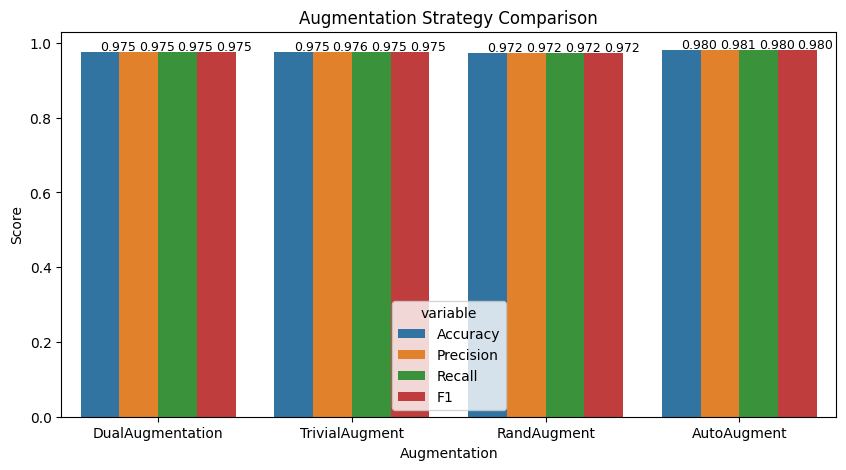

In [ ]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Augmentation Strategies
# =========================
from torchvision.transforms import TrivialAugmentWide, RandAugment, AutoAugment, AutoAugmentPolicy

# 1. Dual Augmentation (custom)
ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
dual_aug1 = transforms.RandomApply([transforms.RandomChoice([
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
    transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
])], p=DUAL_AUG1_PROB)

dual_aug2 = transforms.RandomApply([transforms.RandomChoice([
    transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
    transforms.RandomVerticalFlip(p=VFLIP_PROB),
    transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
])], p=DUAL_AUG2_PROB)

train_trans_dual = transforms.Compose(
    train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
)

# 2. TrivialAugment
train_trans_trivial = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 3. RandAugment
train_trans_rand = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# 4. AutoAugment
train_trans_auto = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    AutoAugment(policy=AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

augmentation_strategies = {
    "DualAugmentation": train_trans_dual,
    "TrivialAugment": train_trans_trivial,
    "RandAugment": train_trans_rand,
    "AutoAugment": train_trans_auto
}

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

X_val_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

# =========================
# LoRA-adapted ViT Head + PolyLoss
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        return self.head(self.dropout(x))

class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=len(CLASS_NAMES), epsilon=0.5, label_smoothing=0.5)

# =========================
# Training Function
# =========================
def train_and_eval(model, train_loader, val_loader, test_loader, optimizer, scheduler, criterion, epochs=50, patience=5):
    best_val_loss = float("inf")
    wait = 0
    best_model_path = "temp_best_model.pth"
    
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.first_step(zero_grad=True)

            logits2 = model(xb)
            loss2 = criterion(logits2, yb)
            loss2.backward()
            optimizer.second_step(zero_grad=True)
            total_loss += loss.item() * xb.size(0)
        epoch_loss = total_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step()
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            wait += 1
            if wait >= patience:
                break

    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    return acc, prec, rec, f1

# =========================
# Execute All Augmentation Strategies
# =========================
results = []
batch_size = 64
in_features = X_val_feats.shape[1]
num_classes = len(CLASS_NAMES)

base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

for aug_name, aug_transform in augmentation_strategies.items():
    print(f"\n=== Training with {aug_name} ===")
    # Extract features for current augmentation
    X_train_feats = np.stack([extract_feature_from_path(p, aug_transform) for p in tqdm(X_train_paths)])
    # Attention-guided Mixup
    X_mix, y_mix = X_train_feats, y_train  # simple baseline, can add AGMixup here if desired
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_mix, dtype=torch.float32),
                                            torch.tensor(y_mix, dtype=torch.long)),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                          torch.tensor(y_val, dtype=torch.long)),
                            batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                           torch.tensor(y_test, dtype=torch.long)),
                             batch_size=batch_size, shuffle=False)

    model_head = ViTHead(in_features, num_classes).to(device)
    optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

    acc, prec, rec, f1 = train_and_eval(model_head, train_loader, val_loader, test_loader,
                                        optimizer, scheduler, criterion)
    results.append({
        "Augmentation": aug_name,
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1
    })

# =========================
# Results Table + Plot
# =========================
import pandas as pd
df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(df)

plt.figure(figsize=(10,5))
sns.barplot(df.melt(id_vars="Augmentation", value_vars=["Accuracy","Precision","Recall","F1"]),
            x="Augmentation", y="value", hue="variable")
plt.title("Augmentation Strategy Comparison")
plt.ylabel("Score")

# Add exact values above bars
for i, row in df.iterrows():
    for j, metric in enumerate(["Accuracy","Precision","Recall","F1"]):
        plt.text(i-0.3+j*0.2, row[metric]+0.005, f"{row[metric]:.3f}", rotation=0, fontsize=9)

plt.show()

Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting validation features...


100%|██████████| 600/600 [01:13<00:00,  8.16it/s]


Validation/Test features shape: (600, 768) (600, 768)

=== Training with DualAugmentation + AGM ===


100%|██████████| 2800/2800 [05:42<00:00,  8.18it/s]



=== Training with TrivialAugment + AGM ===


...


=== Training with RandAugment + AGM ===


100%|██████████| 2800/2800 [05:30<00:00,  8.47it/s]



=== Training with AutoAugment + AGM ===


100%|██████████| 2800/2800 [06:57<00:00,  6.71it/s]



Final Comparison with AGM:
       Augmentation  Accuracy  Precision    Recall        F1
0  DualAugmentation  0.985000   0.985143  0.985000  0.984952
1    TrivialAugment  0.975000   0.976043  0.975000  0.974824
2       RandAugment  0.970000   0.970620  0.970000  0.970012
3       AutoAugment  0.978333   0.978657  0.978333  0.978225


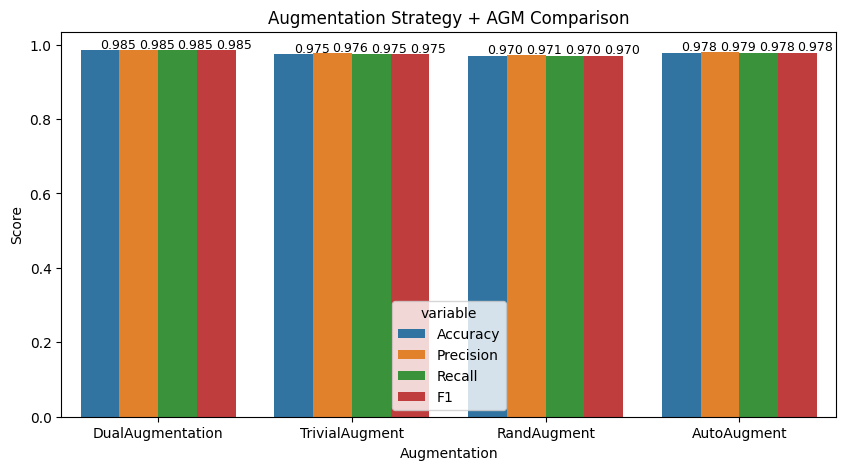

In [3]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Augmentation Strategies
# =========================
from torchvision.transforms import TrivialAugmentWide, RandAugment, AutoAugment, AutoAugmentPolicy

# Dual Augmentation parameters
ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

# Base resize
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

dual_aug1 = transforms.RandomApply([transforms.RandomChoice([
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
    transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
])], p=DUAL_AUG1_PROB)

dual_aug2 = transforms.RandomApply([transforms.RandomChoice([
    transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
    transforms.RandomVerticalFlip(p=VFLIP_PROB),
    transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
])], p=DUAL_AUG2_PROB)

train_trans_dual = transforms.Compose(train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
train_trans_trivial = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), TrivialAugmentWide(), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
train_trans_rand = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), RandAugment(num_ops=2, magnitude=9), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
train_trans_auto = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), AutoAugment(policy=AutoAugmentPolicy.IMAGENET), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])

augmentation_strategies = {
    "DualAugmentation": train_trans_dual,
    "TrivialAugment": train_trans_trivial,
    "RandAugment": train_trans_rand,
    "AutoAugment": train_trans_auto
}

val_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

# Pre-extract validation and test features (reuse)
print("Extracting validation features...")
X_val_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])
print("Validation/Test features shape:", X_val_feats.shape, X_test_feats.shape)

# =========================
# LoRA ViT Head + PolyLoss
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=len(CLASS_NAMES), epsilon=0.5, label_smoothing=0.5)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # label of first
    return np.array(mixX), np.array(mixy)

# =========================
# Training Function
# =========================
def train_and_eval(model, train_loader, val_loader, test_loader, optimizer, scheduler, criterion, epochs=50, patience=5):
    best_val_loss = float("inf")
    wait = 0
    best_model_path = "temp_best_model.pth"
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.first_step(zero_grad=True)

            logits2 = model(xb)
            loss2 = criterion(logits2, yb)
            loss2.backward()
            optimizer.second_step(zero_grad=True)

            total_loss += loss.item() * xb.size(0)
        epoch_loss = total_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(torch.load(best_model_path))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
    return acc, prec, rec, f1

# =========================
# Execute All Augmentation Strategies
# =========================
results = []
batch_size = 64
in_features = X_val_feats.shape[1]
num_classes = len(CLASS_NAMES)

base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

for aug_name, aug_transform in augmentation_strategies.items():
    print(f"\n=== Training with {aug_name} + AGM ===")
    # Extract features for current augmentation
    X_train_feats = np.stack([extract_feature_from_path(p, aug_transform) for p in tqdm(X_train_paths)])

    # Apply AGM
    mixup_count = len(X_train_feats) * 2
    X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_mix, dtype=torch.float32), torch.tensor(y_mix, dtype=torch.long)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=batch_size, shuffle=False)

    model_head = ViTHead(in_features, num_classes).to(device)
    optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

    acc, prec, rec, f1 = train_and_eval(model_head, train_loader, val_loader, test_loader, optimizer, scheduler, criterion)
    results.append({
        "Augmentation": aug_name,
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1
    })

# =========================
# Results Table + Plot
# =========================
df = pd.DataFrame(results)
print("\nFinal Comparison with AGM:")
print(df)

plt.figure(figsize=(10,5))
sns.barplot(df.melt(id_vars="Augmentation", value_vars=["Accuracy","Precision","Recall","F1"]),
            x="Augmentation", y="value", hue="variable")
plt.title("Augmentation Strategy + AGM Comparison")
plt.ylabel("Score")

for i, row in df.iterrows():
    for j, metric in enumerate(["Accuracy","Precision","Recall","F1"]):
        plt.text(i-0.3+j*0.2, row[metric]+0.005, f"{row[metric]:.3f}", rotation=0, fontsize=9)
plt.show()
